# Demystifying Model Behavior: From Simple Genetics to Complex Epistasis

Welcome to this interactive notebook! In this space, we are going to explore exactly how machine learning models and explainability tools behave when we shift the underlying "ground truth" of categorical data. 

In the real world of genomics and bioinformatics, we often feed discrete data (like genotypes coded as 0, 1, and 2) into an algorithm like XGBoost and hope it finds the true biological patterns. But how do we know *what* the model is actually learning? To answer this, we are going to play the role of the "Creator." We will generate synthetic datasets where **we know the exact biological mechanisms** governing the target trait (y). 

By knowing the absolute, indisputable truth, we can test how well Traditional Statistics (OLS) and Machine Learning (XGBoost + SHAP) uncover that truth across three increasingly realistic biological scenarios.

## The Three Scenarios We Will Explore

We will run an end-to-end analytical pipeline—training, evaluating, and explaining—on the following three cases:

### Case 1: The Mendelian World (Pure Main Effects)
* **The Reality:** The target y is driven by independent genes acting alone. These genes might have an additive effect (a straight line from 0 to 2), a dominant effect (having one copy is the same as having two), or a recessive effect (you need both copies to see the trait).
* **The Goal:** Establish a baseline. We will see how traditional OLS handles standard additive traits perfectly, but might slightly misinterpret purely dominant or recessive traits, while XGBoost captures the exact categorical steps. 

### Case 2: The Complex Biological World (Epistatic Interactions)
* **The Reality:** Genes do not act in a vacuum; they interact with one another to influence the target (e.g., Gene A only turns on if Gene B is also present, known as epistasis). 
* **The Goal:** Observe the divergence between traditional stats and machine learning. OLS will struggle to see the gene-gene interaction without manual feature engineering, while XGBoost's tree structure will naturally map the combination. We will use SHAP interaction values to crack open the model and visualize exactly how these genes are working together.

### Case 3: The Incomplete World (Missing Heritability / Hidden Features)
* **The Reality:** We generate a complex dataset with interactions, but deliberately *hide* critical contributing genes from the model. 
* **The Goal:** Mimic messy, real-world clinical scenarios where we simply lack all the necessary genetic sequencing or environmental data. We will watch our evaluation metrics (like R-squared and MSE) degrade, and use SHAP to see how the model tries (and often fails) to compensate for the missing puzzle pieces.

## Our Toolkit
To accomplish this, we will be utilizing:
* **Custom Generators:** `numpy` and `pandas` to build the exact biological equations and categorical genotypes.
* **Baseline Modeling:** `statsmodels` (OLS) for traditional statistical significance and coefficient mapping.
* **Predictive Modeling:** `xgboost` to natively handle categorical data and capture non-linear step functions and complex interactions.
* **Explainability:** `shap` (SHapley Additive exPlanations) to trace global feature importance, visualize specific biological distributions via violin plots, and isolate pure variable interactions.

In [1]:
from XAI_test_2 import *

## simple linear combination test

### make example data 1

In [2]:
# 1. Generate Data
X, _, y, visible_features, _ = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-3, 3), 
    num_interactions=(0, 0), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (2.45 * Feature_0 [recessive]) + 
  (-2.06 * Feature_3 [dominant]) + 
  (-1.52 * Feature_9 [dominant]) + 
  (0.18 * Feature_8 [dominant]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     1376.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:55:06   Log-Likelihood:                -2177.1
No. Observations:                4000   AIC:                             4376.
Df Residuals:                    3989   BIC:                             4445.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

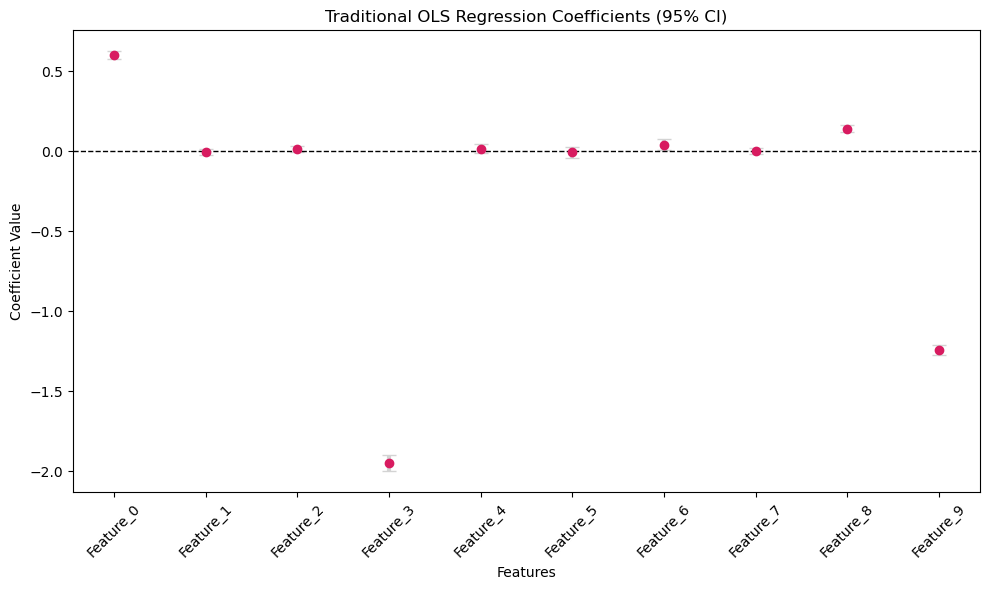

OLS Significant Features: {'Feature_0': {'pvalue': 0.0, 'coefficient': 0.6020349417909228}, 'Feature_3': {'pvalue': 0.0, 'coefficient': -1.9486811168339837}, 'Feature_9': {'pvalue': 0.0, 'coefficient': -1.2424075574610036}, 'Feature_8': {'pvalue': 9.321972632895615e-38, 'coefficient': 0.1417303124772813}, 'Feature_6': {'pvalue': 0.01761538394286578, 'coefficient': 0.04161004009904583}}


In [3]:

# 2. Traditional Baseline (OLS)
ols_model, significant_features = perform_traditional_regression(X_train, y_train)

print("OLS Significant Features:", significant_features)


### make a simple xgboost model for test 1

In [4]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.9871
MSE: 0.0108



### look at XGBoost Native Importances

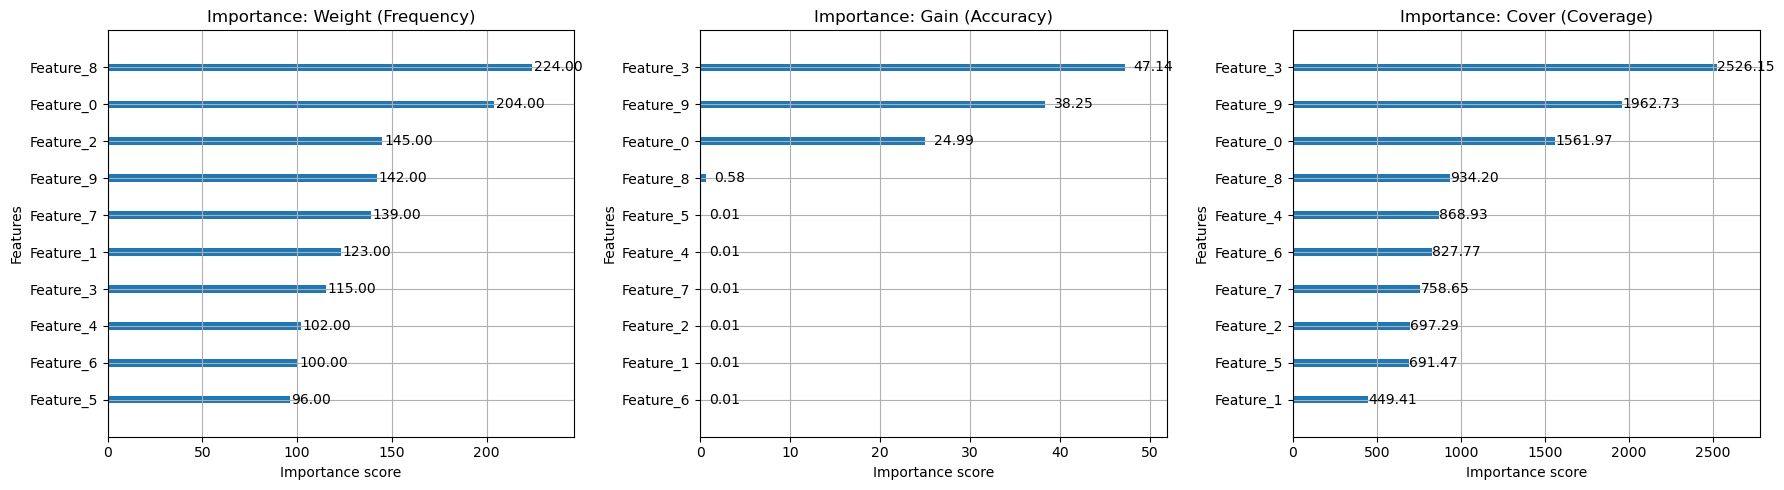

XGBoost Weight Importance: {'Feature_0': 204.0, 'Feature_1': 123.0, 'Feature_2': 145.0, 'Feature_3': 115.0, 'Feature_4': 102.0, 'Feature_5': 96.0, 'Feature_6': 100.0, 'Feature_7': 139.0, 'Feature_8': 224.0, 'Feature_9': 142.0}
XGBoost Gain Importance: {'Feature_0': 24.990880966186523, 'Feature_1': 0.010753866285085678, 'Feature_2': 0.01085332315415144, 'Feature_3': 47.14155578613281, 'Feature_4': 0.012181409634649754, 'Feature_5': 0.01335765328258276, 'Feature_6': 0.009384211152791977, 'Feature_7': 0.011631501838564873, 'Feature_8': 0.5804153680801392, 'Feature_9': 38.25163650512695}
XGBoost Cover Importance: {'Feature_0': 1561.9656982421875, 'Feature_1': 449.406494140625, 'Feature_2': 697.2896728515625, 'Feature_3': 2526.147705078125, 'Feature_4': 868.931396484375, 'Feature_5': 691.46875, 'Feature_6': 827.77001953125, 'Feature_7': 758.6546630859375, 'Feature_8': 934.1964111328125, 'Feature_9': 1962.732421875}


In [5]:

# 5.2 XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [6]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

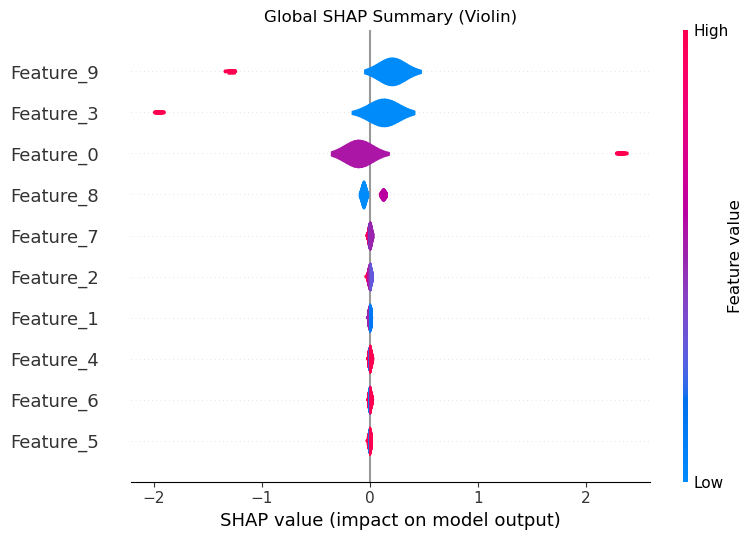

In [7]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


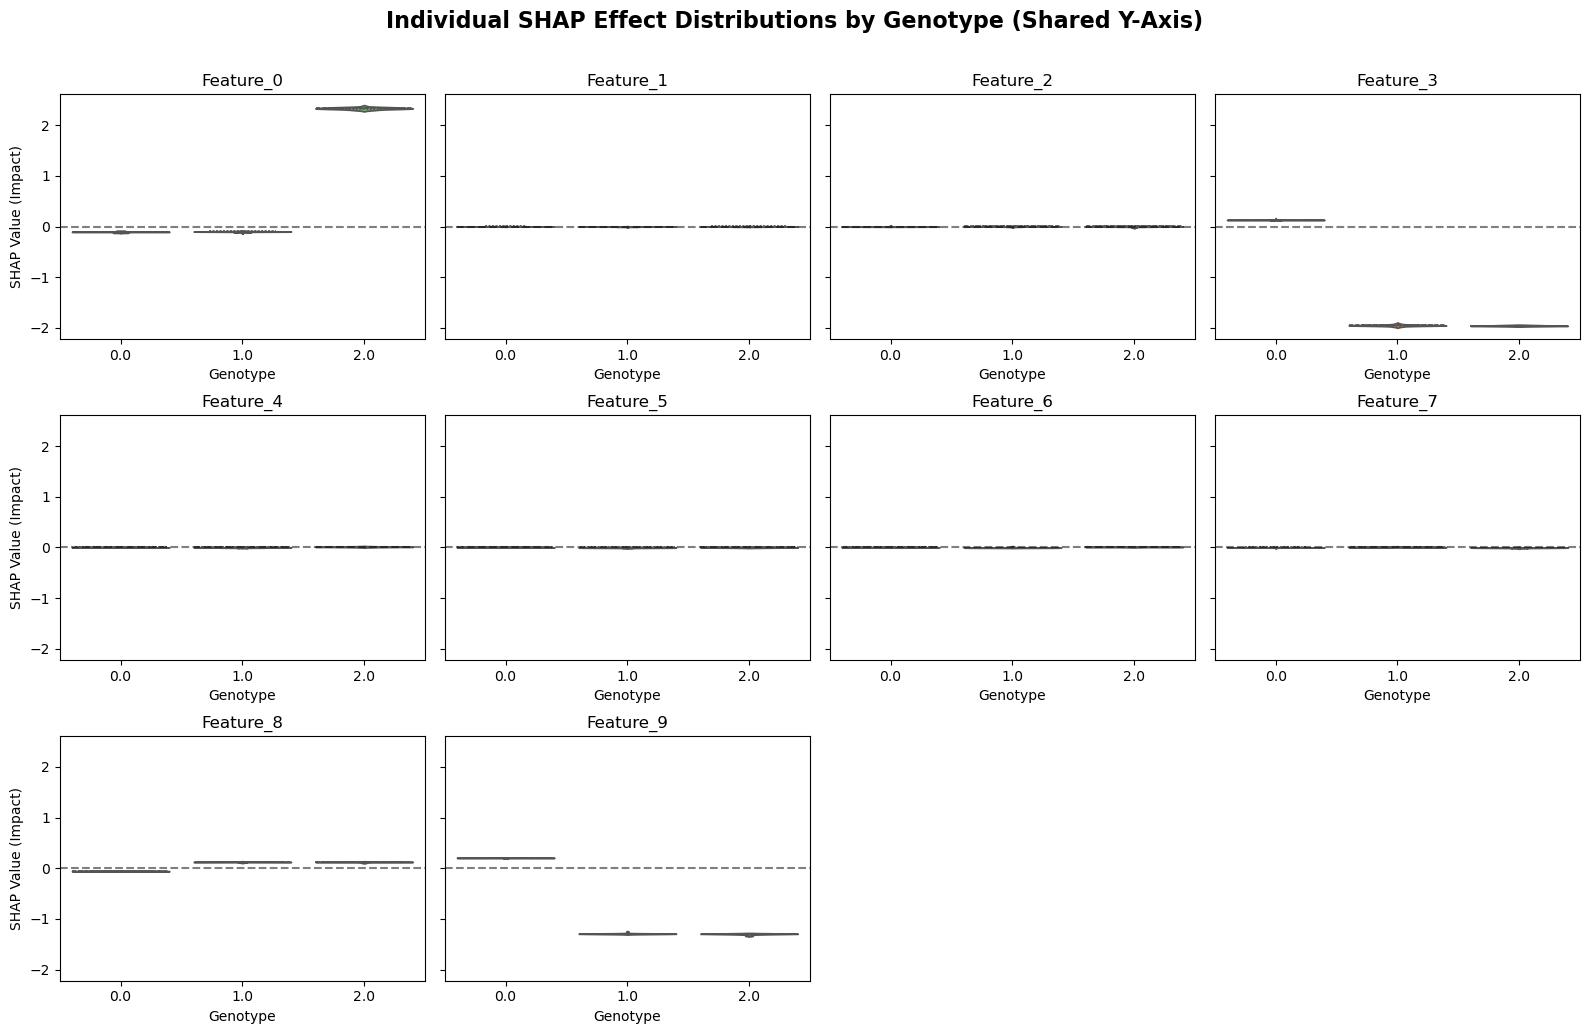

In [8]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


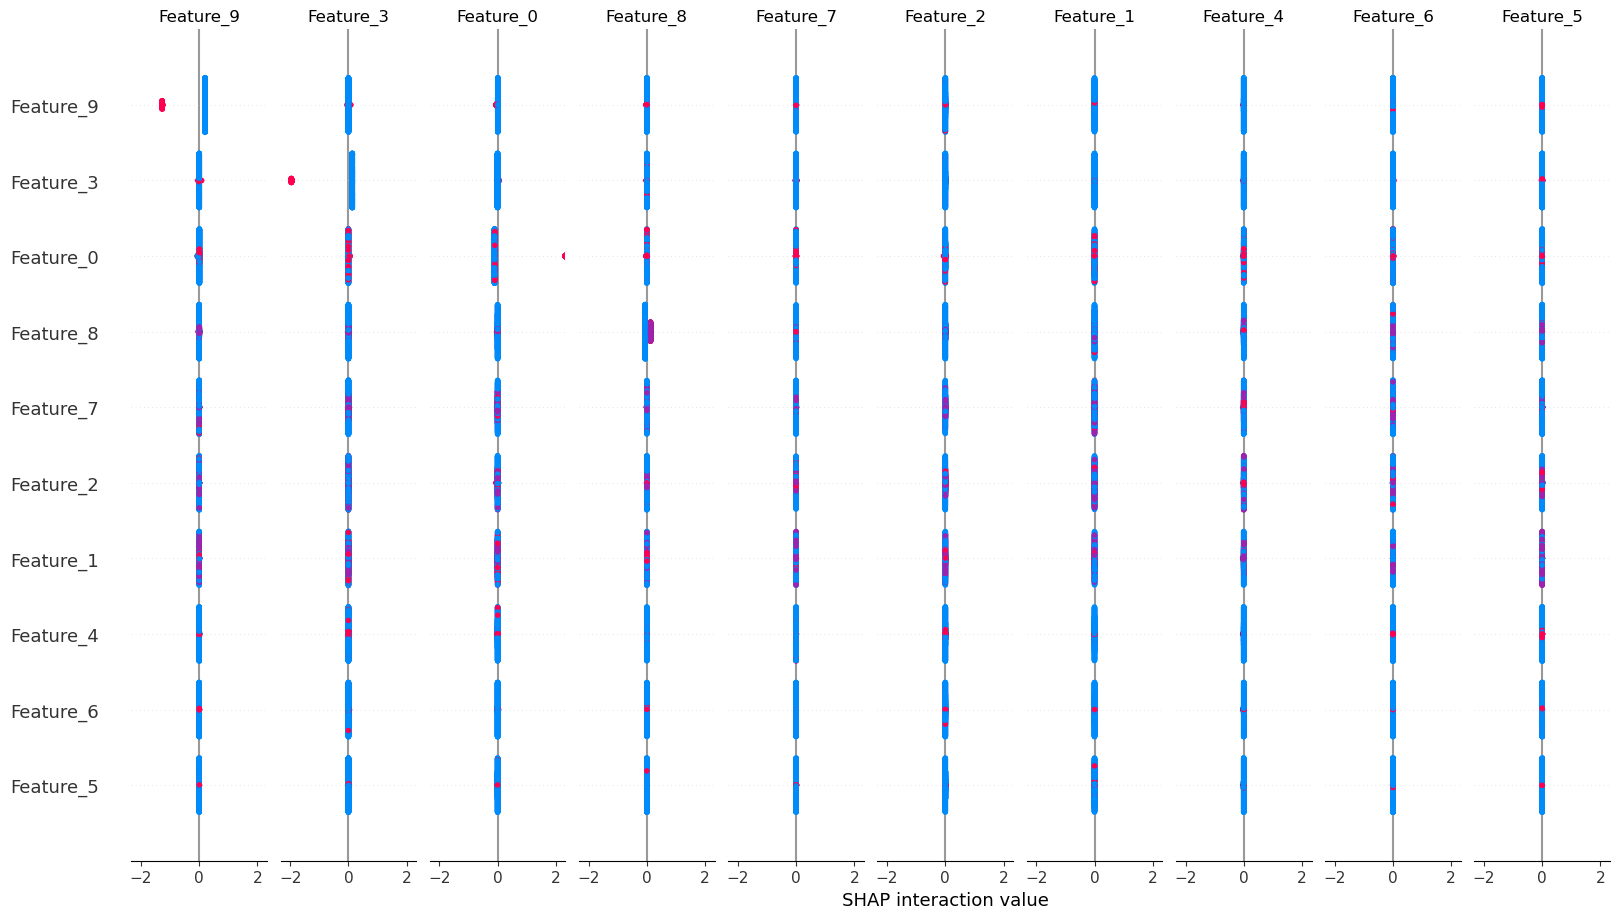


Strongest Interaction found by SHAP: Feature_0 & Feature_9
Plotting pure interaction effect for Feature_0 and Feature_9...


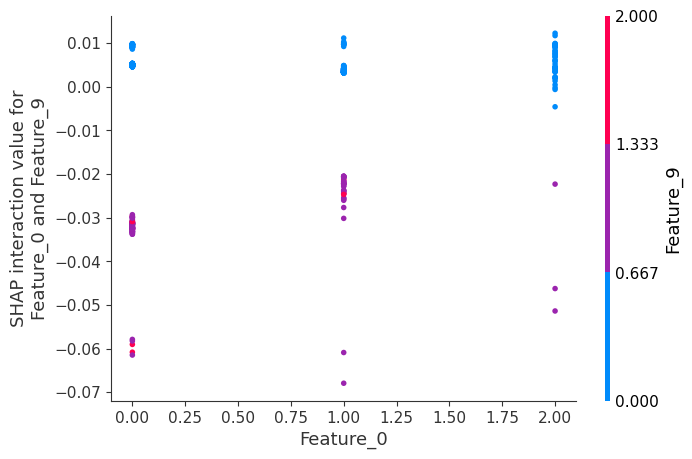


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_0 * Feature_9: 0.008545
  Feature_0 * Feature_3: 0.004423
  Feature_3 * Feature_9: 0.003322
  Feature_0 * Feature_2: 0.002206
  Feature_1 * Feature_4: 0.002025
  Feature_2 * Feature_5: 0.001855
  Feature_0 * Feature_8: 0.001735
  Feature_0 * Feature_7: 0.001585
  Feature_8 * Feature_9: 0.001510
  Feature_2 * Feature_7: 0.001479
-------------------------------------------------

Interaction Effects:
 {'Feature_0 * Feature_9': 0.008544782176613808, 'Feature_0 * Feature_3': 0.004422842059284449, 'Feature_3 * Feature_9': 0.003321997355669737, 'Feature_0 * Feature_2': 0.002205879893153906, 'Feature_1 * Feature_4': 0.0020254813134670258, 'Feature_2 * Feature_5': 0.001854876521974802, 'Feature_0 * Feature_8': 0.001734939287416637, 'Feature_0 * Feature_7': 0.0015845154412090778, 'Feature_8 * Feature_9': 0.0015101406024768949, 'Feature_2 * Feature_7': 0.0014787301188334823, 'Feature_7 * Feature_8': 0.0

In [9]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [10]:

# Print numerical ranking and save the list!
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_9              0.347941     0.0    868   0.204591  0.001561  0.197051  0.204434     0.204801  0.205408  0.207938
Feature_9              0.347941     1.0    115  -1.289918  0.007664 -1.302027 -1.294003    -1.290372 -1.286922 -1.244776
Feature_9              0.347941     2.0     17  -1.295025  0.010965 -1.332845 -1.295930    -1.290781 -1.289335 -1.287837
Feature_3              0.272019     0.0    922   0.130135  0.002609  0.123244  0.129947     0.130430  0.130769  0.164546
Feature_3              0.272019     1.0     74  -1.948790  0.013308 -1.986524 -1.953912    -1.949563 -1.943208 -1.904913
Feature_3              0.272019     2.0      4  -1.955969  0.007032 -1.962922 -1.958773    -1.957390 -1.954586 -1.946173
Feature_0              0.208914     0.0    709  -0.105786  0.008090 -0.130601 -0.105854    -0.10

### SHAP STATISTICAL VALIDATION

#### Permutation Test

In [11]:
shap_pvalues = compute_shap_pvalues(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    true_shap_values=shap_values, 
    feature_names=visible_features, 
    n_permutations=50 # Increase to 100 or 500 for more robust (but slower) results
)

print("SHAP Feature P-values:", shap_pvalues)



--- Calculating Empirical SHAP p-values (Permutations: 50) ---

SHAP Empirical P-values (< 0.05 is statistically significant):
  - Feature_0: 0.0196 *
  - Feature_3: 0.0196 *
  - Feature_8: 0.0196 *
  - Feature_9: 0.0196 *
  - Feature_1: 1.0000 
  - Feature_2: 1.0000 
  - Feature_4: 1.0000 
  - Feature_5: 1.0000 
  - Feature_6: 1.0000 
  - Feature_7: 1.0000 
----------------------------------------------------

SHAP Feature P-values: {'Feature_0': 0.0196078431372549, 'Feature_3': 0.0196078431372549, 'Feature_8': 0.0196078431372549, 'Feature_9': 0.0196078431372549, 'Feature_1': 1.0, 'Feature_2': 1.0, 'Feature_4': 1.0, 'Feature_5': 1.0, 'Feature_6': 1.0, 'Feature_7': 1.0}


#### Boruta Method

In [12]:
shadow_results = compute_shap_shadow_features(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features
)

print("SHAP Shadow Feature Results:", shadow_results)



--- Running SHAP Shadow Feature Analysis ---
Maximum Shadow Feature Importance (Noise Threshold): 0.0024

Shadow Feature Significance Results:
  - Feature_0: 0.2089 -> PASSED (Significant)
  - Feature_1: 0.0013 -> FAILED (Noise)
  - Feature_2: 0.0020 -> FAILED (Noise)
  - Feature_3: 0.2719 -> PASSED (Significant)
  - Feature_4: 0.0011 -> FAILED (Noise)
  - Feature_5: 0.0005 -> FAILED (Noise)
  - Feature_6: 0.0006 -> FAILED (Noise)
  - Feature_7: 0.0023 -> FAILED (Noise)
  - Feature_8: 0.0778 -> PASSED (Significant)
  - Feature_9: 0.3477 -> PASSED (Significant)
----------------------------------------------

SHAP Shadow Feature Results: {'Feature_0': True, 'Feature_1': False, 'Feature_2': False, 'Feature_3': True, 'Feature_4': False, 'Feature_5': False, 'Feature_6': False, 'Feature_7': False, 'Feature_8': True, 'Feature_9': True}


#### Confidence Intervals

In [13]:
bootstrap_results = compute_shap_bootstrapping(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features,
    n_bootstraps=30 # Adjust based on how long you want to wait
)

print("SHAP Bootstrapping Results:", bootstrap_results)



--- Running SHAP Bootstrapping Analysis (Iterations: 30) ---

SHAP Bootstrapped 95% Confidence Intervals:
  - Feature_9: 0.3489 (95% CI: [0.3363, 0.3590])
  - Feature_3: 0.2691 (95% CI: [0.2588, 0.2824])
  - Feature_0: 0.2068 (95% CI: [0.1922, 0.2240])
  - Feature_8: 0.0780 (95% CI: [0.0756, 0.0805])
  - Feature_7: 0.0035 (95% CI: [0.0014, 0.0055])
  - Feature_2: 0.0031 (95% CI: [0.0019, 0.0048])
  - Feature_1: 0.0028 (95% CI: [0.0014, 0.0045])
  - Feature_4: 0.0020 (95% CI: [0.0012, 0.0028])
  - Feature_6: 0.0015 (95% CI: [0.0009, 0.0026])
  - Feature_5: 0.0013 (95% CI: [0.0008, 0.0020])
-------------------------------------------------------

SHAP Bootstrapping Results: {'Feature_9': (0.3488815496365229, 0.3362571507692337, 0.3590049296617508), 'Feature_3': (0.26906493107477825, 0.25877620950341224, 0.2824438698589802), 'Feature_0': (0.20683355132738748, 0.19223970472812651, 0.2239505860954523), 'Feature_8': (0.07797988504171371, 0.07564363162964582, 0.08048909064382315), 'Feature_7

## test for linear combination with some feature interactions

### make example data 2

In [14]:
# 1. Generate Data
X, _, y, visible_features, _ = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-3, 3), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (-2.99 * Feature_8 [additive]) + 
  (-2.59 * Feature_4 [dominant]) + 
  (1.86 * Feature_7 [additive]) + 
  (0.18 * Feature_3 [additive]) + 
  (1.44 * (Feature_0, Feature_4) [xor_interference]) + 
  (0.28 * (Feature_0, Feature_4) [xor_interference]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     4114.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:55:41   Log-Likelihood:                -2753.9
No. Observations:                4000   AIC:                             5530.
Df Residuals:                    3989   BIC:                             5599.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

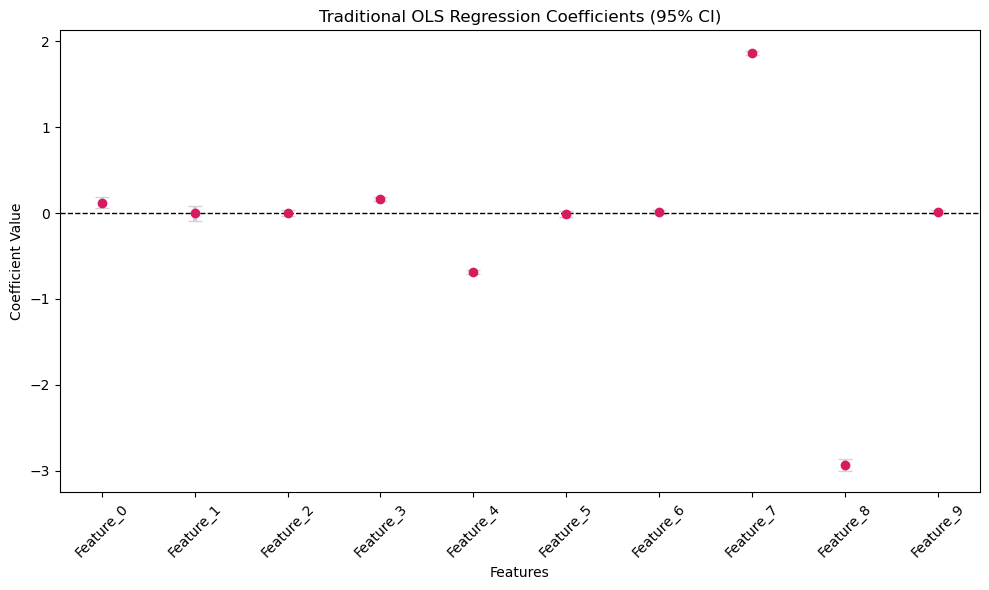

OLS Significant Features: {'Feature_4': {'pvalue': 0.0, 'coefficient': -0.6850584810504399}, 'Feature_7': {'pvalue': 0.0, 'coefficient': 1.8616214761418697}, 'Feature_8': {'pvalue': 0.0, 'coefficient': -2.934089177138363}, 'Feature_3': {'pvalue': 1.0423752624057947e-53, 'coefficient': 0.16601914527538864}, 'Feature_0': {'pvalue': 5.66012416505262e-05, 'coefficient': 0.1218831456371623}}


In [15]:

# 2. Traditional Baseline (OLS)
ols_model, significant_features = perform_traditional_regression(X_train, y_train)

print("OLS Significant Features:", significant_features)


### make a simple xgboost model for test 2

In [16]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.9959
MSE: 0.0114



### look at XGBoost Native Importances

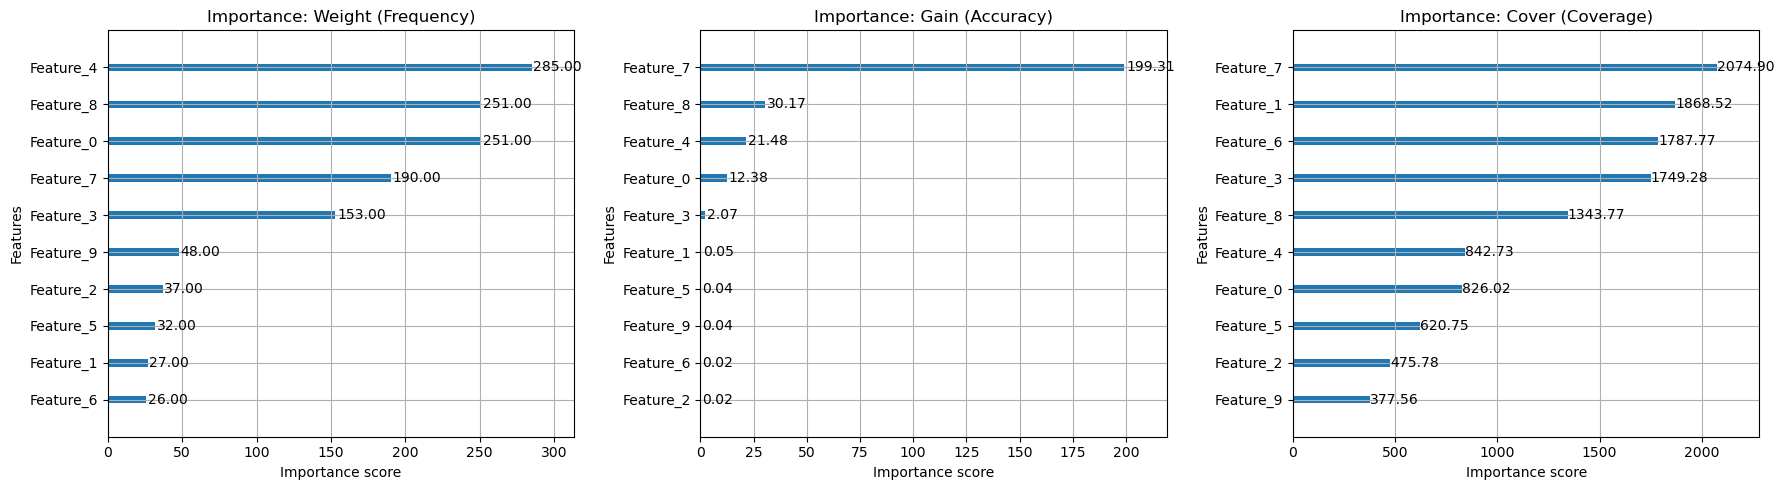

XGBoost Weight Importance: {'Feature_0': 251.0, 'Feature_1': 27.0, 'Feature_2': 37.0, 'Feature_3': 153.0, 'Feature_4': 285.0, 'Feature_5': 32.0, 'Feature_6': 26.0, 'Feature_7': 190.0, 'Feature_8': 251.0, 'Feature_9': 48.0}
XGBoost Gain Importance: {'Feature_0': 12.382027626037598, 'Feature_1': 0.054621219635009766, 'Feature_2': 0.020657997578382492, 'Feature_3': 2.07230281829834, 'Feature_4': 21.48206329345703, 'Feature_5': 0.03912265598773956, 'Feature_6': 0.02395356073975563, 'Feature_7': 199.31387329101562, 'Feature_8': 30.166522979736328, 'Feature_9': 0.0360877625644207}
XGBoost Cover Importance: {'Feature_0': 826.02392578125, 'Feature_1': 1868.5185546875, 'Feature_2': 475.7837829589844, 'Feature_3': 1749.281005859375, 'Feature_4': 842.726318359375, 'Feature_5': 620.75, 'Feature_6': 1787.769287109375, 'Feature_7': 2074.89990234375, 'Feature_8': 1343.77294921875, 'Feature_9': 377.5625}


In [17]:

# 5.2 XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [18]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

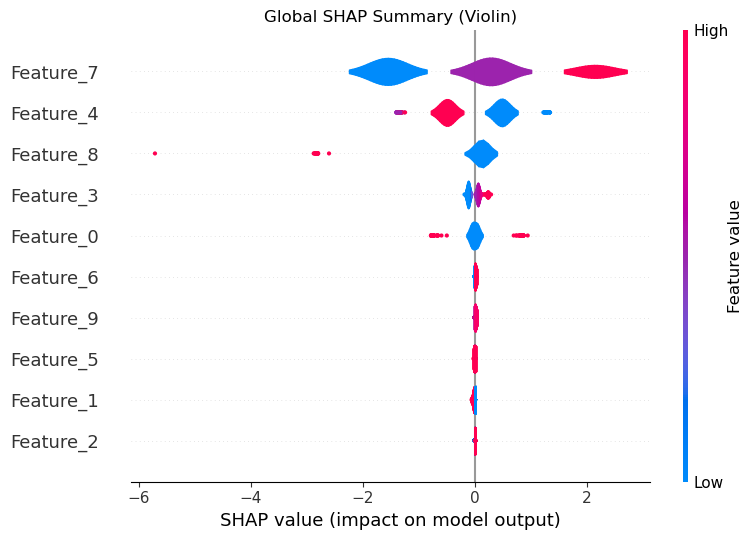

In [19]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


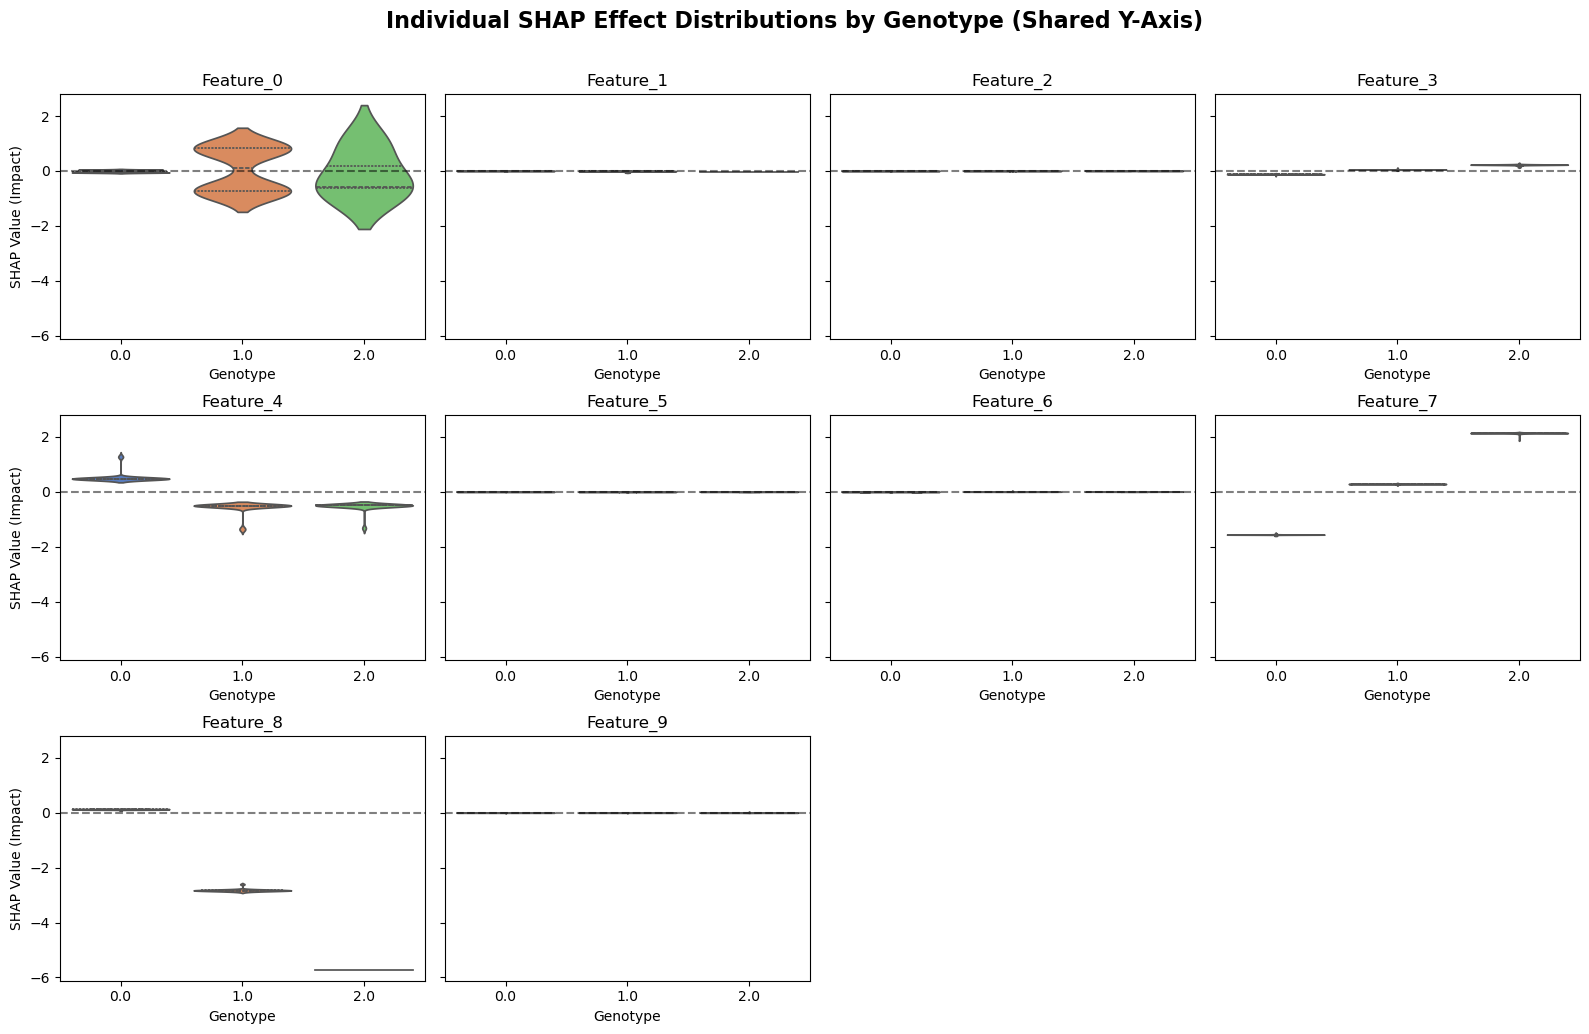

In [20]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


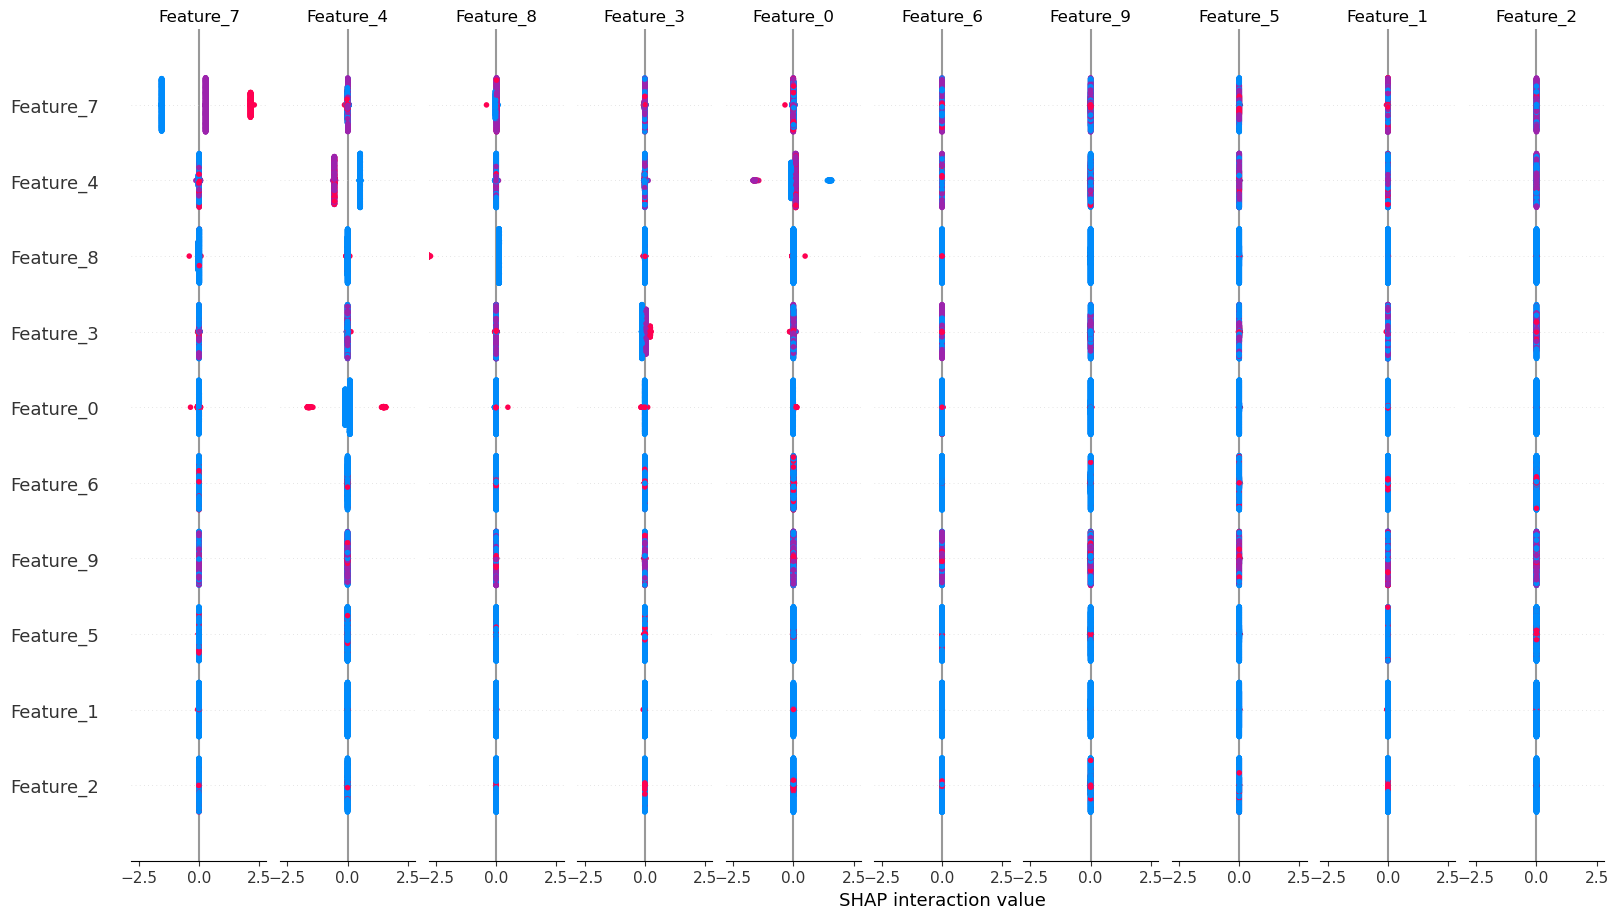


Strongest Interaction found by SHAP: Feature_0 & Feature_4
Plotting pure interaction effect for Feature_0 and Feature_4...


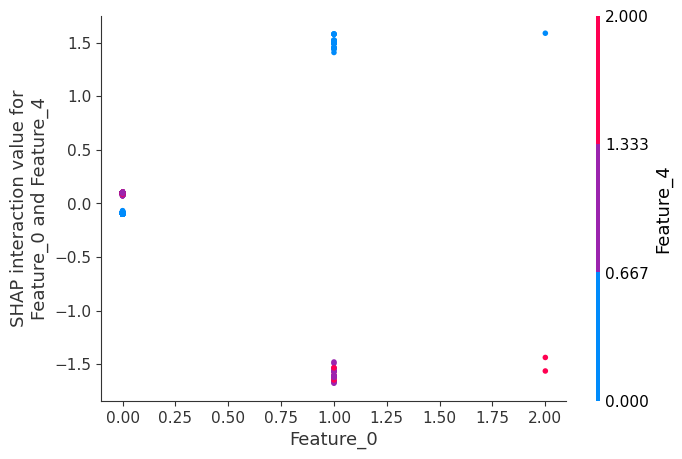


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_0 * Feature_4: 0.177530
  Feature_7 * Feature_8: 0.017796
  Feature_0 * Feature_7: 0.008639
  Feature_4 * Feature_7: 0.008354
  Feature_0 * Feature_3: 0.004648
  Feature_3 * Feature_7: 0.004309
  Feature_3 * Feature_4: 0.004200
  Feature_0 * Feature_8: 0.003797
  Feature_4 * Feature_8: 0.003098
  Feature_3 * Feature_8: 0.001566
-------------------------------------------------

Interaction Effects:
 {'Feature_0 * Feature_4': 0.17753012478351593, 'Feature_7 * Feature_8': 0.017796162515878677, 'Feature_0 * Feature_7': 0.008638904429972172, 'Feature_4 * Feature_7': 0.008353525772690773, 'Feature_0 * Feature_3': 0.004647827707231045, 'Feature_3 * Feature_7': 0.00430868798866868, 'Feature_3 * Feature_4': 0.004199706017971039, 'Feature_0 * Feature_8': 0.0037965457886457443, 'Feature_4 * Feature_8': 0.003097666660323739, 'Feature_3 * Feature_8': 0.001565546845085919, 'Feature_3 * Feature_9': 0.001324

In [21]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [22]:

# Print numerical ranking and save the list!
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_7              1.147662     0.0    400  -1.557306  0.009901 -1.601634 -1.559546    -1.558841 -1.556209 -1.487023
Feature_7              1.147662     1.0    409   0.283316  0.006491  0.243800  0.281408     0.282910  0.286379  0.317295
Feature_7              1.147662     2.0    191   2.140645  0.021283  1.873959  2.138202     2.139874  2.144353  2.169171
Feature_4              0.535417     0.0    506   0.523030  0.183549  0.452129  0.476119     0.478106  0.484593  1.338409
Feature_4              0.535417     1.0    354  -0.556018  0.211142 -1.402665 -0.502510    -0.500606 -0.499052 -0.491431
Feature_4              0.535417     2.0    140  -0.528099  0.168014 -1.376315 -0.495910    -0.494852 -0.492511 -0.476628
Feature_8              0.210330     0.0    968   0.120967  0.009779  0.082109  0.111627     0.12

### SHAP STATISTICAL VALIDATION

#### Permutation Test

In [23]:
shap_pvalues = compute_shap_pvalues(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    true_shap_values=shap_values, 
    feature_names=visible_features, 
    n_permutations=50 # Increase to 100 or 500 for more robust (but slower) results
)

print("SHAP Feature P-values:", shap_pvalues)



--- Calculating Empirical SHAP p-values (Permutations: 50) ---



SHAP Empirical P-values (< 0.05 is statistically significant):
  - Feature_0: 0.0196 *
  - Feature_3: 0.0196 *
  - Feature_4: 0.0196 *
  - Feature_7: 0.0196 *
  - Feature_8: 0.0196 *
  - Feature_1: 1.0000 
  - Feature_2: 1.0000 
  - Feature_5: 1.0000 
  - Feature_6: 1.0000 
  - Feature_9: 1.0000 
----------------------------------------------------

SHAP Feature P-values: {'Feature_0': 0.0196078431372549, 'Feature_3': 0.0196078431372549, 'Feature_4': 0.0196078431372549, 'Feature_7': 0.0196078431372549, 'Feature_8': 0.0196078431372549, 'Feature_1': 1.0, 'Feature_2': 1.0, 'Feature_5': 1.0, 'Feature_6': 1.0, 'Feature_9': 1.0}


#### Boruta Method

In [24]:
shadow_results = compute_shap_shadow_features(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features
)

print("SHAP Shadow Feature Results:", shadow_results)



--- Running SHAP Shadow Feature Analysis ---
Maximum Shadow Feature Importance (Noise Threshold): 0.0016

Shadow Feature Significance Results:
  - Feature_0: 0.0866 -> PASSED (Significant)
  - Feature_1: 0.0003 -> FAILED (Noise)
  - Feature_2: 0.0001 -> FAILED (Noise)
  - Feature_3: 0.1076 -> PASSED (Significant)
  - Feature_4: 0.5351 -> PASSED (Significant)
  - Feature_5: 0.0004 -> FAILED (Noise)
  - Feature_6: 0.0020 -> PASSED (Significant)
  - Feature_7: 1.1478 -> PASSED (Significant)
  - Feature_8: 0.2103 -> PASSED (Significant)
  - Feature_9: 0.0006 -> FAILED (Noise)
----------------------------------------------

SHAP Shadow Feature Results: {'Feature_0': True, 'Feature_1': False, 'Feature_2': False, 'Feature_3': True, 'Feature_4': True, 'Feature_5': False, 'Feature_6': True, 'Feature_7': True, 'Feature_8': True, 'Feature_9': False}


#### Confidence Intervals

In [25]:
bootstrap_results = compute_shap_bootstrapping(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features,
    n_bootstraps=30 # Adjust based on how long you want to wait
)

print("SHAP Bootstrapping Results:", bootstrap_results)



--- Running SHAP Bootstrapping Analysis (Iterations: 30) ---

SHAP Bootstrapped 95% Confidence Intervals:
  - Feature_7: 1.1489 (95% CI: [1.1384, 1.1626])
  - Feature_4: 0.5341 (95% CI: [0.5276, 0.5399])
  - Feature_8: 0.2094 (95% CI: [0.1934, 0.2294])
  - Feature_3: 0.1082 (95% CI: [0.1044, 0.1112])
  - Feature_0: 0.0868 (95% CI: [0.0815, 0.0922])
  - Feature_6: 0.0030 (95% CI: [0.0009, 0.0065])
  - Feature_9: 0.0020 (95% CI: [0.0009, 0.0029])
  - Feature_2: 0.0013 (95% CI: [0.0005, 0.0033])
  - Feature_5: 0.0013 (95% CI: [0.0006, 0.0022])
  - Feature_1: 0.0007 (95% CI: [0.0002, 0.0017])
-------------------------------------------------------

SHAP Bootstrapping Results: {'Feature_7': (1.148853635787964, 1.138403621315956, 1.1626290112733841), 'Feature_4': (0.5340763688087463, 0.5275970324873924, 0.539875103533268), 'Feature_8': (0.20944229811429976, 0.19341141656041144, 0.22937987074255942), 'Feature_3': (0.10817389090855917, 0.1043984241783619, 0.11121140737086534), 'Feature_0': (0

## test for addition of hidden features

### make example data 3

In [26]:
# 1. Generate Data
X, X_hidden, y, visible_features, hidden_features = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(1, 2), 
    weight_range=(-3, 3), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=True,           
    hidden_in_interactions=True
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (-2.19 * Feature_5 [recessive]) + 
  (1.53 * Feature_1 [dominant]) + 
  (1.50 * Feature_0 [dominant]) + 
  (-1.49 * Hidden_1 [additive]) + 
  (-0.89 * Feature_4 [dominant]) + 
  (0.65 * Feature_9 [additive]) + 
  (-0.03 * Hidden_0 [additive]) + 
  (0.45 * (Feature_0, Feature_8) [recessive_epistasis]) + 
  (-0.37 * (Feature_6, Hidden_1) [multiplicative]) + 
  (-0.25 * (Feature_7, Hidden_0) [dominant_epistasis]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     417.1
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:56:17   Log-Likelihood:                -6090.1
No. Observations:                4000   AIC:                         1.220e+04
Df Residuals:                    3989   BIC:                         1.227e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

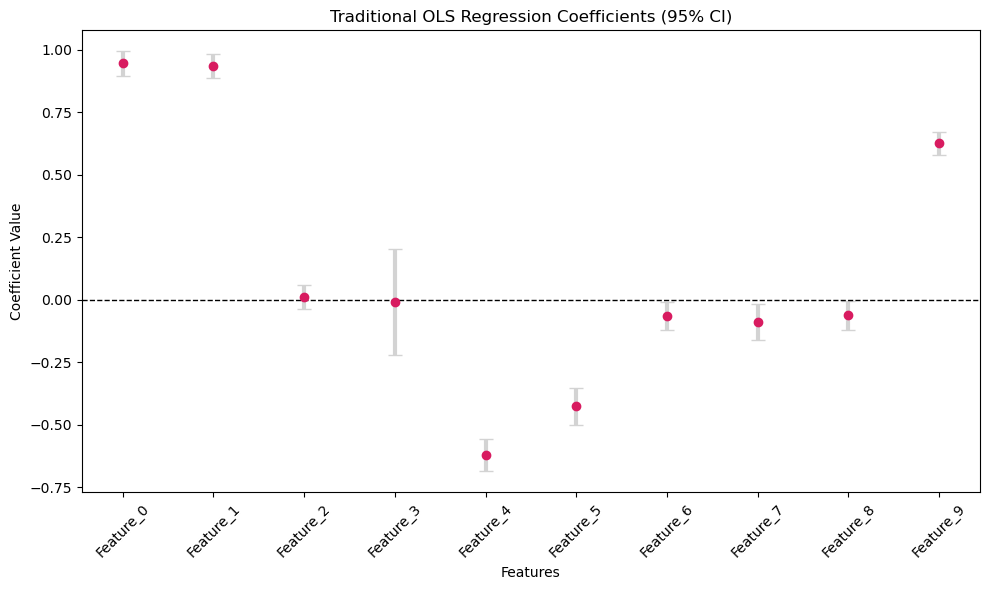

OLS Significant Features: {'Feature_1': {'pvalue': 5.5318086711468465e-272, 'coefficient': 0.9359099132658582}, 'Feature_0': {'pvalue': 5.497119276815886e-271, 'coefficient': 0.9457750275854756}, 'Feature_9': {'pvalue': 1.1489587712736432e-135, 'coefficient': 0.6256774140626897}, 'Feature_4': {'pvalue': 1.3048412341666228e-76, 'coefficient': -0.6228199954990663}, 'Feature_5': {'pvalue': 3.014622885230089e-29, 'coefficient': -0.42694772858939706}, 'Feature_7': {'pvalue': 0.01629993598474505, 'coefficient': -0.08875024991845272}, 'Feature_6': {'pvalue': 0.01950272850596777, 'coefficient': -0.06523281989774762}, 'Feature_8': {'pvalue': 0.0384144320320968, 'coefficient': -0.06318876063488583}}


In [27]:

# 2. Traditional Baseline (OLS)
ols_model, significant_features = perform_traditional_regression(X_train, y_train)

print("OLS Significant Features:", significant_features)


### make a simple xgboost model for test 3

In [28]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.6330
MSE: 0.9949



### look at XGBoost Native Importances

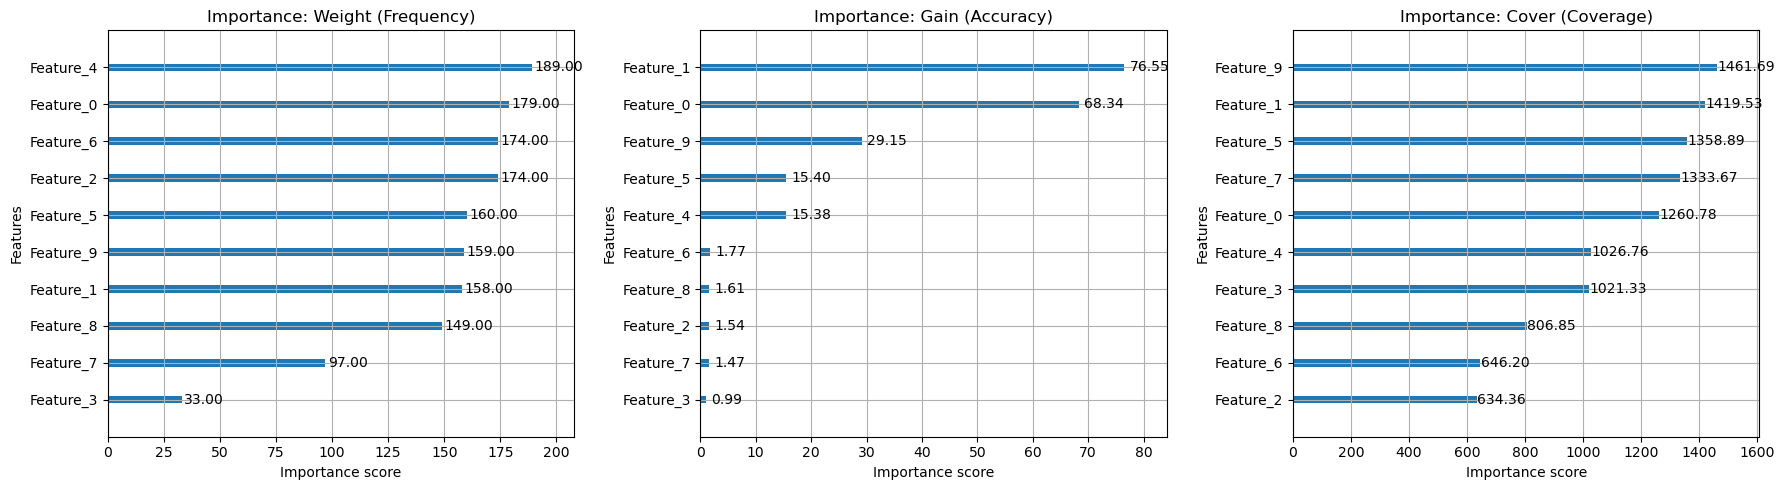

XGBoost Weight Importance: {'Feature_0': 179.0, 'Feature_1': 158.0, 'Feature_2': 174.0, 'Feature_3': 33.0, 'Feature_4': 189.0, 'Feature_5': 160.0, 'Feature_6': 174.0, 'Feature_7': 97.0, 'Feature_8': 149.0, 'Feature_9': 159.0}
XGBoost Gain Importance: {'Feature_0': 68.34423828125, 'Feature_1': 76.54887390136719, 'Feature_2': 1.544547438621521, 'Feature_3': 0.9869879484176636, 'Feature_4': 15.383771896362305, 'Feature_5': 15.396059036254883, 'Feature_6': 1.7659260034561157, 'Feature_7': 1.465433955192566, 'Feature_8': 1.6056241989135742, 'Feature_9': 29.14628791809082}
XGBoost Cover Importance: {'Feature_0': 1260.7764892578125, 'Feature_1': 1419.5252685546875, 'Feature_2': 634.3563232421875, 'Feature_3': 1021.3333129882812, 'Feature_4': 1026.761962890625, 'Feature_5': 1358.887451171875, 'Feature_6': 646.201171875, 'Feature_7': 1333.6700439453125, 'Feature_8': 806.8456420898438, 'Feature_9': 1461.685546875}


In [29]:

# 5.2 XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [30]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

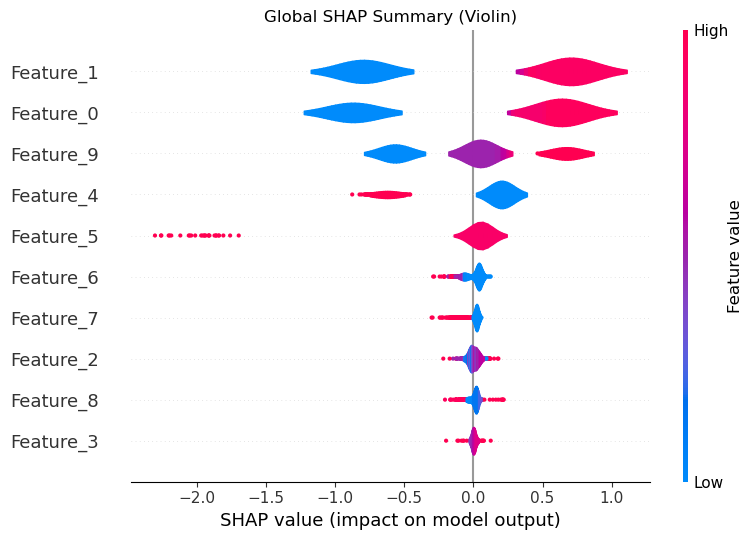

In [31]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


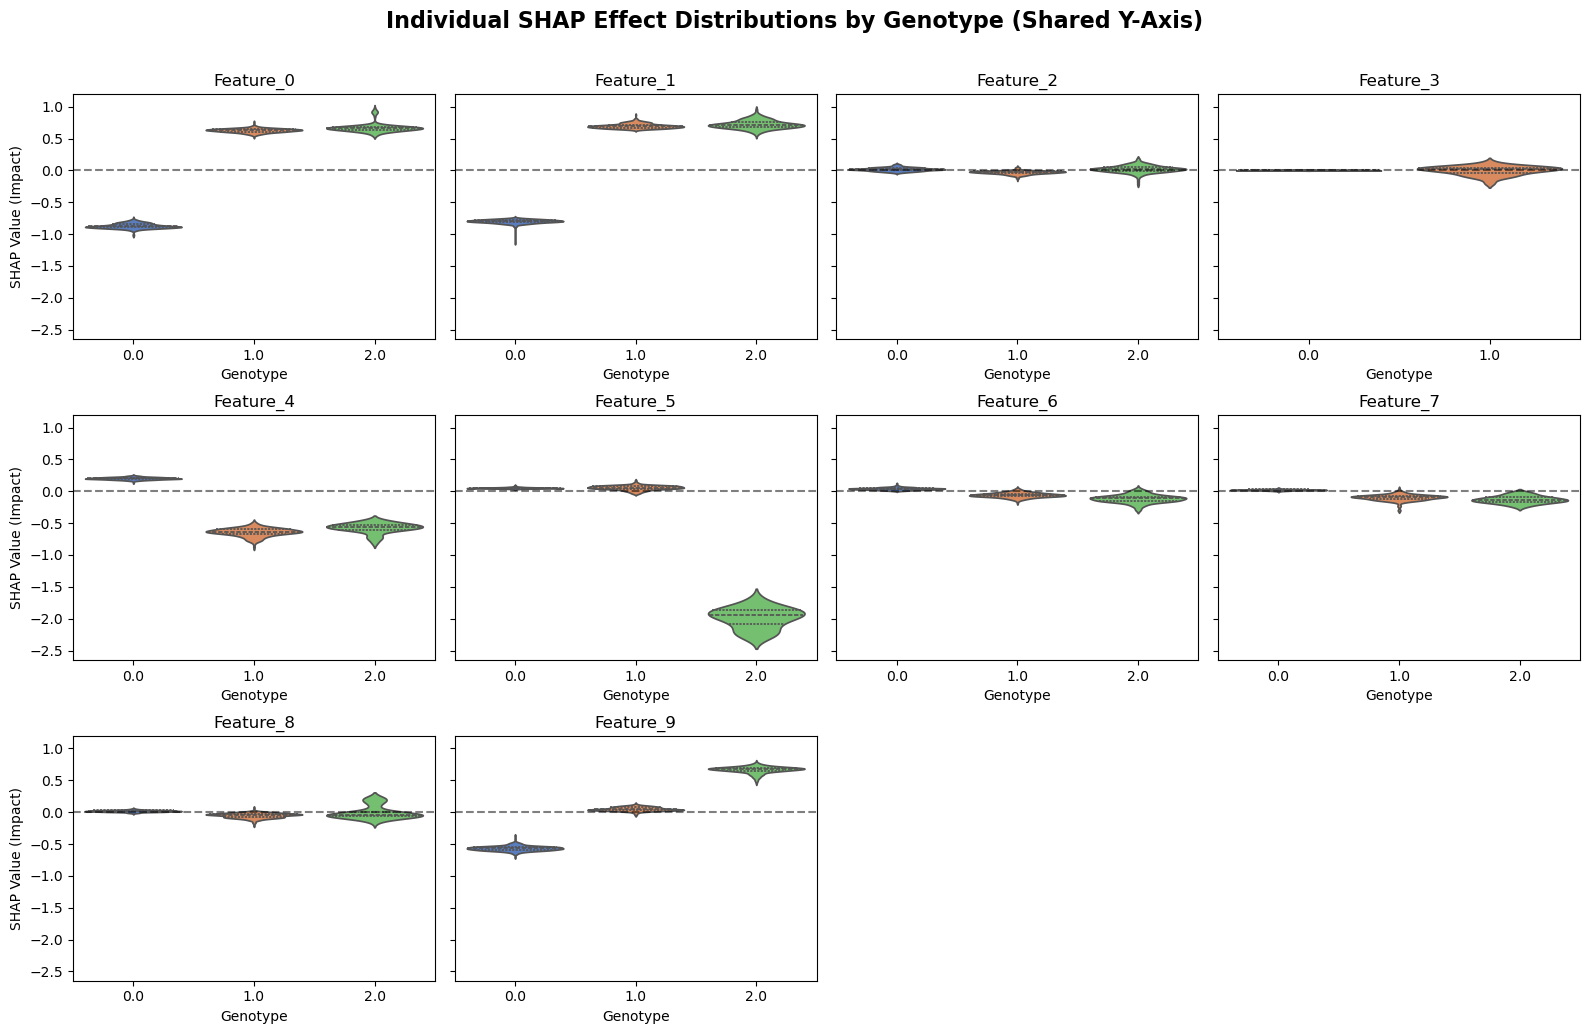

In [32]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


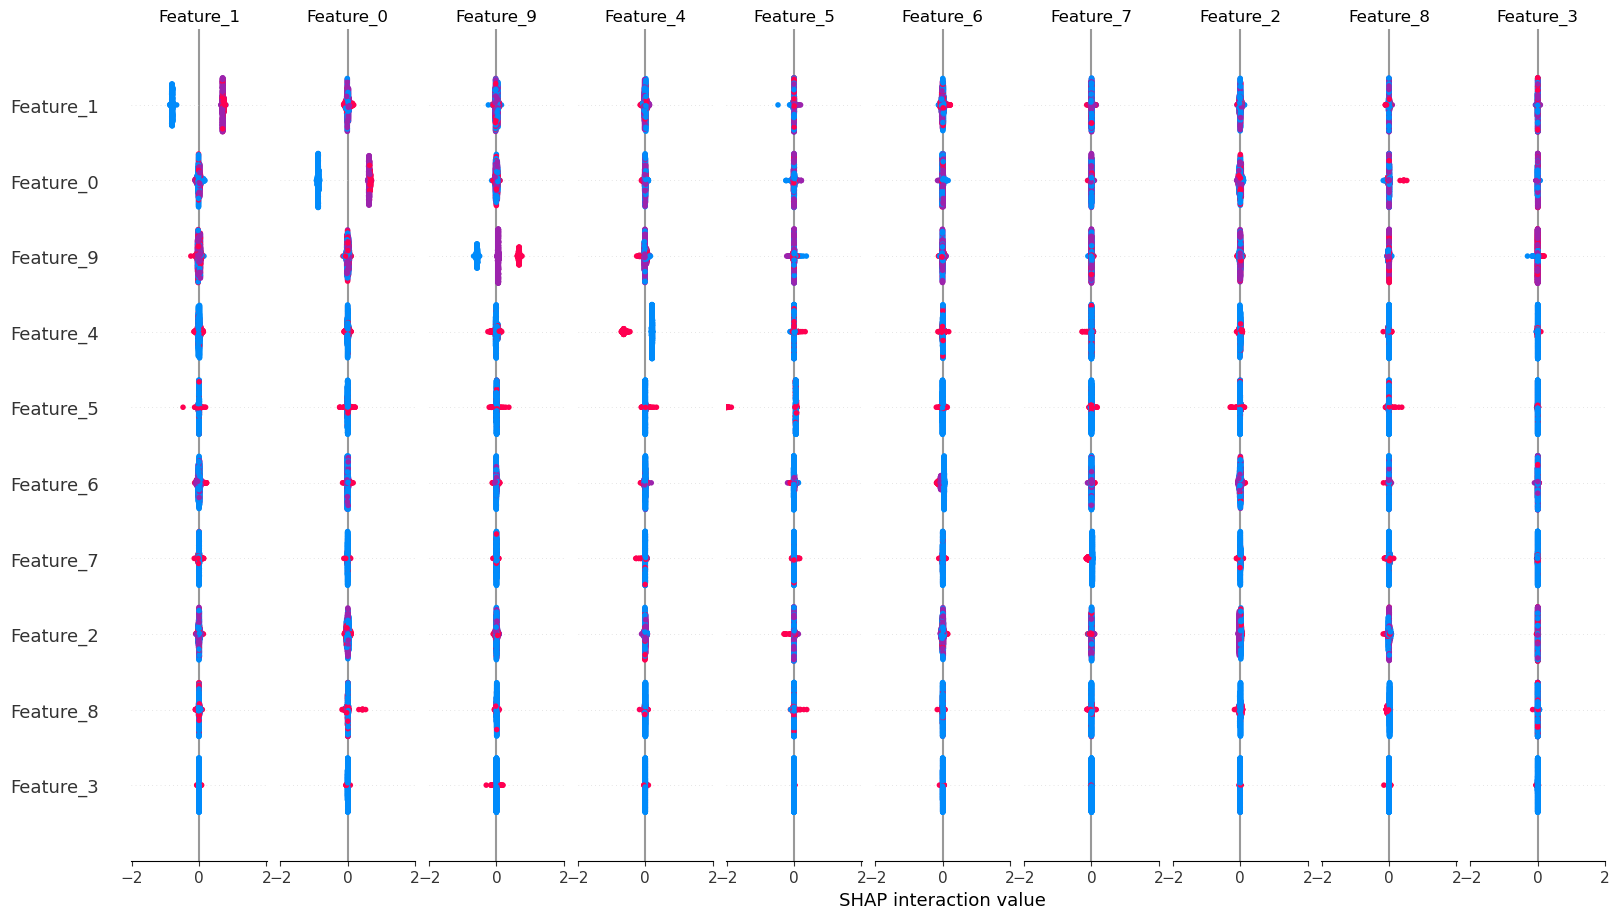


Strongest Interaction found by SHAP: Feature_1 & Feature_9
Plotting pure interaction effect for Feature_1 and Feature_9...


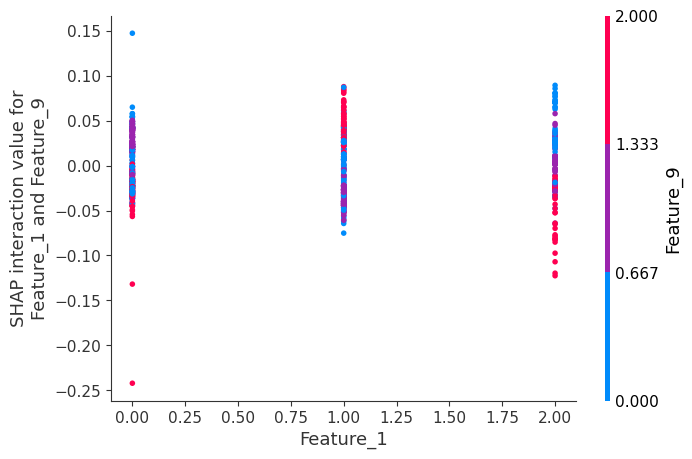


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_1 * Feature_9: 0.030528
  Feature_4 * Feature_9: 0.029081
  Feature_0 * Feature_1: 0.027600
  Feature_1 * Feature_6: 0.024862
  Feature_1 * Feature_4: 0.024327
  Feature_0 * Feature_2: 0.023852
  Feature_0 * Feature_9: 0.020515
  Feature_2 * Feature_8: 0.019194
  Feature_2 * Feature_6: 0.017683
  Feature_1 * Feature_2: 0.015667
-------------------------------------------------

Interaction Effects:
 {'Feature_1 * Feature_9': 0.030528195202350616, 'Feature_4 * Feature_9': 0.029080888256430626, 'Feature_0 * Feature_1': 0.027600064873695374, 'Feature_1 * Feature_6': 0.024862423539161682, 'Feature_1 * Feature_4': 0.024327365681529045, 'Feature_0 * Feature_2': 0.023851748555898666, 'Feature_0 * Feature_9': 0.020515259355306625, 'Feature_2 * Feature_8': 0.019193612039089203, 'Feature_2 * Feature_6': 0.017683032900094986, 'Feature_1 * Feature_2': 0.015666760504245758, 'Feature_0 * Feature_4': 0.01566

In [33]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [34]:

# Print numerical ranking and save the list!
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_1              0.747879     0.0    451  -0.797919  0.030487 -1.143308 -0.812667    -0.795861 -0.778966 -0.736456
Feature_1              0.747879     1.0    386   0.699701  0.036153  0.633959  0.673048     0.693978  0.717834  0.871277
Feature_1              0.747879     2.0    163   0.723514  0.065953  0.553702  0.679581     0.716591  0.765306  0.955444
Feature_0              0.735774     0.0    413  -0.870879  0.038670 -1.025427 -0.895311    -0.879682 -0.844502 -0.750898
Feature_0              0.735774     1.0    428   0.629471  0.030636  0.523404  0.610631     0.631160  0.649458  0.761378
Feature_0              0.735774     2.0    159   0.670992  0.068978  0.550669  0.639974     0.662259  0.682156  0.975043
Feature_9              0.349899     0.0    311  -0.566529  0.037633 -0.704363 -0.590557    -0.56

### SHAP STATISTICAL VALIDATION

#### Permutation Test

In [35]:
shap_pvalues = compute_shap_pvalues(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    true_shap_values=shap_values, 
    feature_names=visible_features, 
    n_permutations=50 # Increase to 100 or 500 for more robust (but slower) results
)

print("SHAP Feature P-values:", shap_pvalues)



--- Calculating Empirical SHAP p-values (Permutations: 50) ---

SHAP Empirical P-values (< 0.05 is statistically significant):
  - Feature_0: 0.0196 *
  - Feature_1: 0.0196 *
  - Feature_4: 0.0196 *
  - Feature_5: 0.0196 *
  - Feature_9: 0.0196 *
  - Feature_7: 0.1373 
  - Feature_6: 0.1765 
  - Feature_8: 0.7843 
  - Feature_2: 0.9412 
  - Feature_3: 1.0000 
----------------------------------------------------

SHAP Feature P-values: {'Feature_0': 0.0196078431372549, 'Feature_1': 0.0196078431372549, 'Feature_4': 0.0196078431372549, 'Feature_5': 0.0196078431372549, 'Feature_9': 0.0196078431372549, 'Feature_7': 0.13725490196078433, 'Feature_6': 0.17647058823529413, 'Feature_8': 0.7843137254901961, 'Feature_2': 0.9411764705882353, 'Feature_3': 1.0}


#### Boruta Method

In [36]:
shadow_results = compute_shap_shadow_features(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features
)

print("SHAP Shadow Feature Results:", shadow_results)



--- Running SHAP Shadow Feature Analysis ---
Maximum Shadow Feature Importance (Noise Threshold): 0.0272

Shadow Feature Significance Results:
  - Feature_0: 0.7278 -> PASSED (Significant)
  - Feature_1: 0.7387 -> PASSED (Significant)
  - Feature_2: 0.0222 -> FAILED (Noise)
  - Feature_3: 0.0022 -> FAILED (Noise)
  - Feature_4: 0.3045 -> PASSED (Significant)
  - Feature_5: 0.1040 -> PASSED (Significant)
  - Feature_6: 0.0475 -> PASSED (Significant)
  - Feature_7: 0.0319 -> PASSED (Significant)
  - Feature_8: 0.0224 -> FAILED (Noise)
  - Feature_9: 0.3503 -> PASSED (Significant)
----------------------------------------------

SHAP Shadow Feature Results: {'Feature_0': True, 'Feature_1': True, 'Feature_2': False, 'Feature_3': False, 'Feature_4': True, 'Feature_5': True, 'Feature_6': True, 'Feature_7': True, 'Feature_8': False, 'Feature_9': True}


#### Confidence Intervals

In [37]:
bootstrap_results = compute_shap_bootstrapping(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features,
    n_bootstraps=30 # Adjust based on how long you want to wait
)

print("SHAP Bootstrapping Results:", bootstrap_results)



--- Running SHAP Bootstrapping Analysis (Iterations: 30) ---

SHAP Bootstrapped 95% Confidence Intervals:
  - Feature_1: 0.7432 (95% CI: [0.7246, 0.7659])
  - Feature_0: 0.7323 (95% CI: [0.7038, 0.7674])
  - Feature_9: 0.3488 (95% CI: [0.3290, 0.3680])
  - Feature_4: 0.3084 (95% CI: [0.2763, 0.3357])
  - Feature_5: 0.1042 (95% CI: [0.0912, 0.1189])
  - Feature_6: 0.0540 (95% CI: [0.0319, 0.0694])
  - Feature_2: 0.0381 (95% CI: [0.0259, 0.0540])
  - Feature_7: 0.0379 (95% CI: [0.0221, 0.0617])
  - Feature_8: 0.0329 (95% CI: [0.0216, 0.0512])
  - Feature_3: 0.0050 (95% CI: [0.0030, 0.0086])
-------------------------------------------------------

SHAP Bootstrapping Results: {'Feature_1': (0.7432439863681793, 0.7245610728859901, 0.7658745795488358), 'Feature_0': (0.7323492765426636, 0.7037695720791817, 0.7674227833747864), 'Feature_9': (0.3487872968117396, 0.32904176190495493, 0.3680106461048126), 'Feature_4': (0.3084126700957616, 0.27631362304091456, 0.33572418093681333), 'Feature_5': (